$$
J(\theta)=\mathbb E_{\tau\sim p_\theta(\tau)}[R(\tau)]
$$

### 对数求导技巧

$$
\begin{split}
J(\theta)&=\mathbb E_{\tau\sim p_\theta(\tau)}[R(\tau)]\\
\nabla_\theta J(\theta)&=\int R(\tau)\nabla_\theta p_\theta(\tau)
\end{split}
$$

- 两大问题：无法遍历，需要环境模型
    - $\nabla p_\theta(\tau)$：无法直接对轨迹分布求导数（其内部是长链条的概率连乘，对于 policy 无法感知 $p(s'|s,a)$）
        - 而且失去了期望形式，无法通过采样的方式计算
    - 而且需要遍历所有的 trajectory
        - 多步骤，动作空间巨大，随机性状态转移导致的组合爆炸
- 对数求导技巧

$$
\begin{split}
\nabla_\theta J(\theta)&=\int R(\tau)\nabla_\theta p_\theta(\tau)\\
&=\int R(\tau) p_\theta(\tau)\nabla_\theta \log p_\theta(\tau)\\
&=\mathbb E_{\tau\sim p_\theta(\tau)}[R(\tau)\nabla_\theta\log p_\theta(\tau)]
\end{split}
$$

- 对期望求导 => 通过对数求导技巧 => 依然保持了期望的形式
- 进一步的 $\nabla_\theta\log p_\theta(\tau)$ 只依赖于策略网络：$\sum_t\nabla_\theta \log\pi_\theta(a_t|s_t)$
    - $\log p_{\theta}(\tau) = \log p(\mathbf{s}_1) + \sum_{t=1}^{T} \left( \log \pi_{\theta}(\mathbf{a}_t|\mathbf{s}_t) + \log p(\mathbf{s}_{t+1}|\mathbf{s}_t, \mathbf{a}_t) \right)$
- 最终得到的 REINFORCE 更新式（基于蒙特卡洛估计）

$$
\nabla_\theta J(\theta)\approx\frac1N\sum_{i=1}^NR(\tau_i)(\sum_t \nabla_\theta\log\pi_\theta(a_{i,t}|s_{i,t}))
$$

### 偏差、方差分析

> unbiased、high-variance

$$\nabla_{\theta} J(\theta) \approx \hat{g} = \frac{1}{N} \sum_{i=1}^{N} \left( \sum_{t=0}^{T-1} \nabla_{\theta} \log \pi_{\theta} (a_{i,t} | s_{i,t}) \right) R(\tau_{i})$$

- unbiased ($N=1$)：在统计和机器学习中，一个估计量（estimator）的“无偏性”指的是，该估计量的期望值（expected value）等于它所要估计的那个真实参数的真实值。
    - 由于无法计算真实梯度（需要遍历所有可能的轨迹），我们通过采样一批轨迹（trajectories）来计算一个梯度的估计值，也就是上面公式定义的 $\hat g$，即证明 $\mathbb E[\hat g]=\nabla_\theta J(\theta)$

$$
\begin{align*}
E_{\tau \sim \pi_{\theta}} [\hat{g}] &= E_{\tau \sim \pi_{\theta}} \left[ \left( \sum_{t=0}^{T-1} \nabla_{\theta} \log \pi_{\theta} (a_t | s_t) \right) R(\tau) \right] \\
&= E_{\tau \sim \pi_{\theta}} [(\nabla_{\theta} \log P(\tau; \theta)) \cdot R(\tau)] \\
&= \sum_{\tau} P(\tau; \theta) [(\nabla_{\theta} \log P(\tau; \theta)) \cdot R(\tau)] \\
&= \sum_{\tau} P(\tau; \theta) \left[ \frac{\nabla_{\theta} P(\tau; \theta)}{P(\tau; \theta)} \cdot R(\tau) \right] \\
&= \sum_{\tau} \nabla_{\theta} P(\tau; \theta) \cdot R(\tau) \\
&= \nabla_{\theta} \left( \sum_{\tau} P(\tau; \theta) \cdot R(\tau) \right) \\
&= \nabla_{\theta} J(\theta)
\end{align*}
$$

- 基础的策略梯度估计具有非常高的方差（High Variance）。
    - 采样的随机性: 策略本身是随机的 ($\pi(a|s)$ 是一个概率分布)，环境的转移也可能是随机的 $p(s'|s,a)$。这导致即使从同一个状态开始，采样到的轨迹 $\tau$ 和对应的回报 $R(\tau)$，也会有巨大的差异。可能这一次采样，智能体运气好，获得了一个很高的回报；下一次采样，运气不好，回报就很低。梯度估计值会随着每一次采样的 $R(\tau)$ 而剧烈波动；
- Credit Assignment 问题:
    - 观察梯度公式，回报 $R(\tau)$ 是整个轨迹的总回报，但它被用来乘以轨迹中每一个动作的 $\nabla_\theta\log\pi_\theta(a_t|s_t)$
    - 这会带来什么问题？ 假设一条轨迹很长，总回报很高。这意味着这条轨迹中所有的动作，无论好坏，其被选择的概率都会被提升。一个在早期步骤的“坏”动作，可能因为后续一系列“好”动作带来了高回报，而被错误地加强。
    - 反之，一个“好”动作，也可能因为后续的坏运气导致总回报很低，而被错误地抑制。
    - 这种“成王败寇”式的更新方式，使得梯度信号的信噪比非常低，带来了巨大的方差。
- 高方差的危害是什么？
    - 训练不稳定: 梯度估计值忽正忽负，大小剧烈变化，导致优化过程非常震荡。
    - 收敛速度慢: 因为单次采样的梯度估计非常不靠谱，为了得到一个比较准确的梯度方向，我们需要采集海量的轨迹（即增大 $N$）来求平均，这使得算法的样本效率（Sample Efficiency）极低。

### 如何降低方差？（偏差与方差的权衡）

- 方法一：利用因果关系（Causality）—— Reward-to-Go
    - 在 $t$ 时刻做出的动作 $a$，理应只影响 $t$ 时刻及之后的回报，和 $t$ 时刻之前的回报无关。
    - 在计算 $t$ 时刻动作的梯度时，我们不应该使用整个轨迹的回报 $R(\tau)$，而只应该使用从这个时刻开始的未来回报总和，即 Reward-to-Go:
        - $G_t=\sum_{k=t}^T\gamma^{k-t}r_t$
    - 梯度估计因此被修改为：$\hat{g} \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{T-1} \nabla_{\theta} \log \pi_{\theta}(a_{i,t} | s_{i,t}) \cdot G_{i,t}$
        - 这个修改不会引入任何偏差（可以数学证明），但通常能显著降低方差，因为它为每个动作分配了更相关的回报。
- 方法二：引入基线（Baseline）
    - 回报的绝对值大小不重要，重要的是某个动作得到的回报比“平均水平”好多少。
    - 我们可以从回报中减去一个基线（Baseline） $b(s_t)$，这个基线只与状态 $s_t$ 有关，与动作 $a_t$无关。
    - $\hat{g} \approx \frac{1}{N} \sum_{i=1}^{N} \sum_{t=0}^{T-1} \nabla_{\theta} \log \pi_{\theta}(a_{i,t} | s_{i,t}) \cdot \left( G_{i,t} - b(s_{i,t}) \right)$

- $R(\tau)=G_t+B_t=\sum_{k=t}^{T-1}r_k+\sum_{k=0}^{t-1}r_k$
$$
\begin{align*}
E[\nabla_{\theta} \log \pi_{\theta}(a_t|s_t)R(\tau)] &= E[\nabla_{\theta} \log \pi_{\theta}(a_t|s_t)(G_t + B_t)] \\
&= E[\nabla_{\theta} \log \pi_{\theta}(a_t|s_t)G_t] + E[\nabla_{\theta} \log \pi_{\theta}(a_t|s_t)B_t] \\
&= E[\nabla_{\theta} \log \pi_{\theta}(a_t|s_t)G_t] + 0
\end{align*}
$$
- $B_t$ 是在 $t$ 之前发生的所有奖励之和，即在 $(s_t,a_t)$ 这对状态-动作对出现之前就已经确定的值，给定 $s_t$ 的情况下，动作 $a_t$ 的选择对 $B_t$ 没有任何影响；
    - 求 $B_t\cdot\nabla_\theta\log \pi_\theta(a_t|s_t)$ 的期望时，可以将 $B_t$ 当做一个常数提出来，
    - $\sum_{a_t}\pi_\theta(a_t|s_t)\nabla_\theta\log\pi_\theta(a_t|s_t)$ 为0
    - $\sum_{a_t}\pi_\theta(a_t|s_t)\nabla_\theta\log\pi_\theta(a_t|s_t)=\sum_{a_t}\pi_\theta(a_t|s_t)\frac{\nabla_\theta\pi_\theta(a_t|s_t)}{\pi_\theta(a_t|s_t)}=\sum_{a_t}\nabla_\theta\pi_\theta(a_t|s_t)=\nabla_\theta\sum_{a_t}\pi_\theta(a_t|s_t)=0$

### coding

- https://dilithjay.com/blog/actor-critic-methods

In [5]:
# policy_gradient_comparison.py

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import time

# --- 1. Hyperparameters ---
ENV_NAME = "CartPole-v1"
LEARNING_RATE_ACTOR = 0.001
LEARNING_RATE_CRITIC = 0.005
GAMMA = 0.99
NUM_EPISODES = 1000
HIDDEN_SIZE = 128
RENDER_EVERY = 200 # 每隔多少个episode渲染一次环境

# --- 2. Model Definitions ---

class PolicyNet(nn.Module):
    """策略网络 (Actor)"""
    def __init__(self, state_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, action_dim)
        )

    def forward(self, state):
        logits = self.network(state)
        # 使用 Categorical 分布来处理离散动作空间
        return Categorical(logits=logits)

class ValueNet(nn.Module):
    """价值网络 (Critic)"""
    def __init__(self, state_dim):
        super(ValueNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, 1)
        )

    def forward(self, state):
        return self.network(state)

# --- 3. Training Function ---

def train(algorithm='reinforce'):
    """
    统一的训练函数
    Args:
        algorithm (str): 'reinforce', 'reward-to-go', or 'actor-critic'
    """
    print(f"\n--- Starting training for: {algorithm.upper()} ---")
    
    # 初始化环境和模型
    env = gym.make(ENV_NAME)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    actor = PolicyNet(state_dim, action_dim)
    optimizer_actor = optim.Adam(actor.parameters(), lr=LEARNING_RATE_ACTOR)

    critic = None
    optimizer_critic = None
    if algorithm == 'actor-critic':
        critic = ValueNet(state_dim)
        optimizer_critic = optim.Adam(critic.parameters(), lr=LEARNING_RATE_CRITIC)

    episode_rewards = []
    
    start_time = time.time()

    for i_episode in range(NUM_EPISODES):
        state, _ = env.reset()
        
        # 存储当前回合的数据
        log_probs = []
        rewards = []
        state_values = [] # 仅用于 actor-critic
        
        # --- 3.1. Collect Trajectory ---
        while True:
            # 渲染 (可选)
            if i_episode > 0 and i_episode % RENDER_EVERY == 0:
                 env.render()

            state_tensor = torch.from_numpy(state).float().unsqueeze(0)
            
            # Actor选择动作
            dist = actor(state_tensor)
            action = dist.sample()
            
            log_probs.append(dist.log_prob(action))

            # Critic评估状态价值
            if algorithm == 'actor-critic':
                state_values.append(critic(state_tensor))

            # 与环境交互
            next_state, reward, terminated, truncated, _ = env.step(action.item())
            rewards.append(reward)
            state = next_state
            
            done = terminated or truncated
            if done:
                break
        
        episode_rewards.append(sum(rewards))

        # --- 3.2. Calculate Loss and Update ---
        
        # 将列表转换为张量
        rewards = torch.tensor(rewards, dtype=torch.float32)
        log_probs = torch.cat(log_probs)

        # 计算损失
        actor_loss = 0
        critic_loss = 0
        
        if algorithm == 'reinforce':
            # 方法1: 基础 REINFORCE
            # 使用整个回合的总回报来更新每一步
            total_return = torch.sum(rewards)
            # 为了稳定，对 returns 进行标准化 (可选但强烈推荐)
            returns = torch.full_like(log_probs, total_return)
            # returns = (returns - returns.mean()) / (returns.std() + 1e-9)
            actor_loss = -torch.sum(log_probs * returns)

        elif algorithm == 'reward-to-go':
            # 方法2: REINFORCE with Reward-to-Go
            # 对每一步，只使用未来的回报
            returns = []
            discounted_reward = 0
            for r in reversed(rewards):
                discounted_reward = r + GAMMA * discounted_reward
                returns.insert(0, discounted_reward)
            
            returns = torch.tensor(returns)
            # 标准化 returns 来降低方差
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)
            
            actor_loss = -torch.sum(log_probs * returns)

        elif algorithm == 'actor-critic':
            # 方法3: Actor-Critic
            # 计算 Reward-to-Go 作为 G_t (TD Target)
            returns = []
            discounted_reward = 0
            for r in reversed(rewards):
                discounted_reward = r + GAMMA * discounted_reward
                returns.insert(0, discounted_reward)

            returns = torch.tensor(returns, dtype=torch.float32)
            state_values = torch.cat(state_values).squeeze()
            
            # 计算优势 Advantage = G_t - V(s_t)
            advantages = returns - state_values
            
            # 计算 Actor loss: -log_prob * advantage
            # .detach() 很重要, 阻止梯度从actor流向critic
            actor_loss = -torch.sum(log_probs * advantages.detach())
            
            # 计算 Critic loss: MSE(G_t, V(s_t))
            critic_loss = nn.MSELoss()(state_values, returns)
            
            # 更新 Critic
            optimizer_critic.zero_grad()
            critic_loss.backward()
            optimizer_critic.step()

        # 更新 Actor
        optimizer_actor.zero_grad()
        actor_loss.backward()
        optimizer_actor.step()
        
        # 打印进度
        if i_episode % 100 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(f'Episode {i_episode}\tAverage Reward (last 100): {avg_reward:.2f}')

    env.close()
    end_time = time.time()
    print(f"Training for {algorithm.upper()} finished in {end_time - start_time:.2f} seconds.")
    return episode_rewards


--- Starting training for: REINFORCE ---
Episode 0	Average Reward (last 100): 71.00
Episode 100	Average Reward (last 100): 23.57


/home/zhangchunhui/miniconda3/envs/verl/lib/python3.10/site-packages/gymnasium/envs/classic_control/cartpole.py:250: UserWarning: WARN: You are calling render method without specifying any render mode. You can specify the render_mode at initialization, e.g. gym.make("CartPole-v1", render_mode="rgb_array")
  gym.logger.warn(


Episode 200	Average Reward (last 100): 31.71
Episode 300	Average Reward (last 100): 47.81
Episode 400	Average Reward (last 100): 72.59
Episode 500	Average Reward (last 100): 94.26
Episode 600	Average Reward (last 100): 136.65
Episode 700	Average Reward (last 100): 149.11
Episode 800	Average Reward (last 100): 186.73
Episode 900	Average Reward (last 100): 194.85
Training for REINFORCE finished in 31.35 seconds.

--- Starting training for: REWARD-TO-GO ---
Episode 0	Average Reward (last 100): 30.00
Episode 100	Average Reward (last 100): 23.08
Episode 200	Average Reward (last 100): 33.95
Episode 300	Average Reward (last 100): 66.07
Episode 400	Average Reward (last 100): 181.56
Episode 500	Average Reward (last 100): 295.67
Episode 600	Average Reward (last 100): 348.89
Episode 700	Average Reward (last 100): 418.09
Episode 800	Average Reward (last 100): 448.31
Episode 900	Average Reward (last 100): 340.96
Training for REWARD-TO-GO finished in 72.32 seconds.

--- Starting training for: ACTOR-

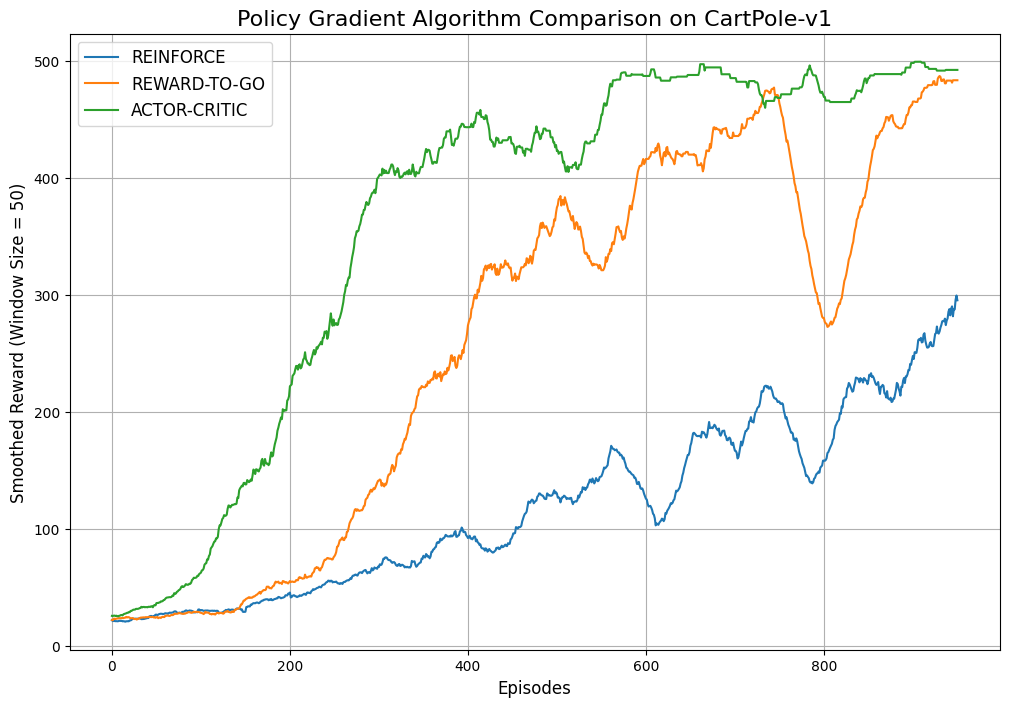

In [6]:

# 存储不同算法的结果
all_results = {}

algorithms_to_run = ['reinforce', 'reward-to-go', 'actor-critic']

for alg in algorithms_to_run:
    # 为了公平比较，为每个算法设置相同的随机种子
    torch.manual_seed(42)
    np.random.seed(42)
    all_results[alg] = train(alg)

# --- 4.1. Plotting ---
plt.figure(figsize=(12, 8))

# 定义滑动平均窗口大小
window_size = 50

for name, rewards in all_results.items():
    # 计算滑动平均值，使曲线更平滑
    moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg, label=name.upper())

plt.title(f'Policy Gradient Algorithm Comparison on {ENV_NAME}', fontsize=16)
plt.xlabel('Episodes', fontsize=12)
plt.ylabel(f'Smoothed Reward (Window Size = {window_size})', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()